<a href="https://colab.research.google.com/github/GlenTarigann/LatihanSertifikasi-Komdigixdigitalent/blob/main/LatihanSertifikasi_Komdigixdigitalent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd

# Membaca file CSV dengan nama yang benar
df = pd.read_csv('/content/Data_Nasabah.csv', sep=';')

# Menampilkan 5 data pertama
df.head(5)

,nasabah_id,umur,jenis_kelamin,pendapatan,saldo_rata_rata,jumlah_transaksi,jenis_produk,frekuensi_kunjungi_cabang,pengguna_mobile_banking,skor_kredit
0,N001,22,Perempuan,5800000,1508000,19,tabungan,1,TIDAK,900
1,N002,64,Perempuan,5700000,1254000,9,kartu_kredit,2,TIDAK,900
2,N003,27,Perempuan,2950000,590000,12,tabungan,1,YA,500
3,N004,34,Perempuan,3100000,186000,16,deposito,5,TIDAK,700
4,N005,45,Laki-Laki,6700000,1474000,15,kartu_kredit,3,YA,800


In [ ]:
import time
from curl_cffi import requests
from bs4 import BeautifulSoup
from datetime import datetime
import pytz

# URL target Detik.com
url = 'https://www.detik.com/edu/seleksi-masuk-pt/d-6661914/10-jurusan-kuliah-yang-gampang-dapat-kerja-ada-yang-kamu-incar'

def perform_scrape_detik(target_url, max_retries=3):
    session = requests.Session()

    for i in range(max_retries):
        try:
            print(f"Mencoba mengakses Detik.com (Percobaan {i+1})...")
            # Menggunakan impersonate chrome untuk menghindari blokir
            response = session.get(target_url, impersonate="chrome110", timeout=30)

            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')

                # Ambil Judul dari meta og:title atau tag h1
                meta_title = soup.find('meta', attrs={'property': 'og:title'})
                title = meta_title['content'] if meta_title else (soup.find('h1').text.strip() if soup.find('h1') else "Judul tidak ditemukan")

                # Ambil Tanggal Publikasi dari meta publishdate
                meta_date = soup.find('meta', attrs={'name': 'publishdate'})
                date_val = meta_date['content'] if meta_date else "Tanggal tidak ditemukan"

                # Ambil Tag/Keywords
                meta_tags = soup.find('meta', attrs={'name': 'keywords'})
                tags = meta_tags['content'] if meta_tags else "Tag tidak ditemukan"

                print("\n--- Hasil Scraping Berhasil ---")
                print("Judul Artikel:", title)
                print("Tanggal Publikasi:", date_val)
                print("Tag:", tags)
                return

            else:
                print(f"Gagal. Status code: {response.status_code}")
                if response.status_code == 202:
                    time.sleep(5)
                else:
                    break

        except Exception as e:
            print(f"Terjadi kesalahan saat scraping: {e}")
            time.sleep(2)

    print("Gagal mendapatkan data setelah beberapa percobaan.")

perform_scrape_detik(url)

In [ ]:
import pandas as pd

# Membaca dataset dengan separator titik koma
df_nasabah = pd.read_csv('/content/Data_Nasabah.csv', sep=';')

# 1. Menampilkan jumlah data
print(f"Jumlah Baris: {df_nasabah.shape[0]}")
print(f"Jumlah Kolom: {df_nasabah.shape[1]}\n")

# 2. Menampilkan tipe data
print("--- Informasi Tipe Data ---")
display(df_nasabah.info())

# 3. Deskripsi statistik dasar
print("\n--- Deskripsi Statistik ---")
display(df_nasabah.describe(include='all'))

In [ ]:
# 4. Menganalisis skema pengkodean (Nilai unik untuk setiap kolom)
print("--- Analisis Nilai Unik (Skema Pengkodean) ---")
for col in df_nasabah.columns:
    unique_vals = df_nasabah[col].unique()
    print(f"\nKolom '{col}' ({df_nasabah[col].dtype}):")
    print(f"  Jumlah nilai unik: {len(unique_vals)}")
    if len(unique_vals) <= 10:
        print(f"  Nilai: {unique_vals}")
    else:
        print(f"  Contoh Nilai: {unique_vals[:5]}...")

In [ ]:
# Melakukan pengkodean pada kolom kategorikal
df_nasabah['jenis_kelamin'] = df_nasabah['jenis_kelamin'].map({'Laki-Laki': 1, 'Perempuan': 2})
df_nasabah['jenis_produk'] = df_nasabah['jenis_produk'].map({'tabungan': 1, 'kartu_kredit': 2, 'deposito': 3})
df_nasabah['pengguna_mobile_banking'] = df_nasabah['pengguna_mobile_banking'].map({'YA': 1, 'TIDAK': 2})

# Memastikan perubahan dengan menampilkan 5 data pertama
display(df_nasabah.head())


Lima Baris Pertama Data:
  nasabah_id  umur jenis_kelamin  pendapatan  saldo_rata_rata  \
0       N001    22     Perempuan     5800000          1508000   
1       N002    64     Perempuan     5700000          1254000   
2       N003    27     Perempuan     2950000           590000   
3       N004    34     Perempuan     3100000           186000   
4       N005    45     Laki-Laki     6700000          1474000   

   jumlah_transaksi  jenis_produk  frekuensi_kunjungi_cabang  \
0                19      tabungan                          1   
1                 9  kartu_kredit                          2   
2                12      tabungan                          1   
3                16      deposito                          5   
4                15  kartu_kredit                          3   

  pengguna_mobile_banking  skor_kredit  
0                   TIDAK          900  
1                   TIDAK          900  
2                      YA          500  
3                   TIDAK         

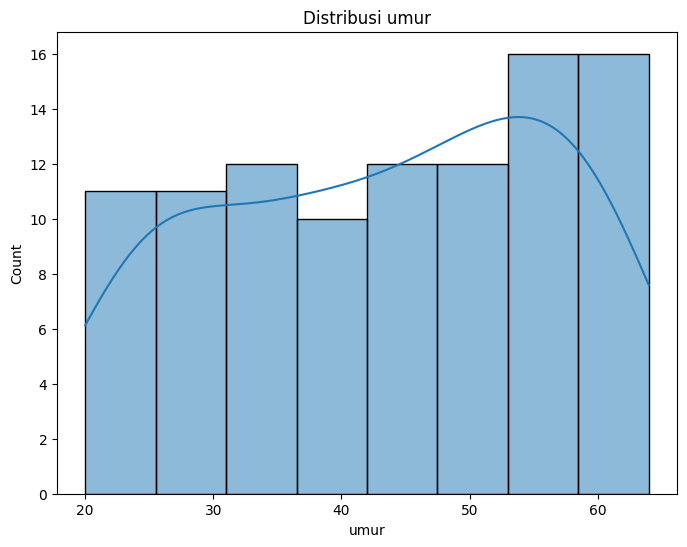

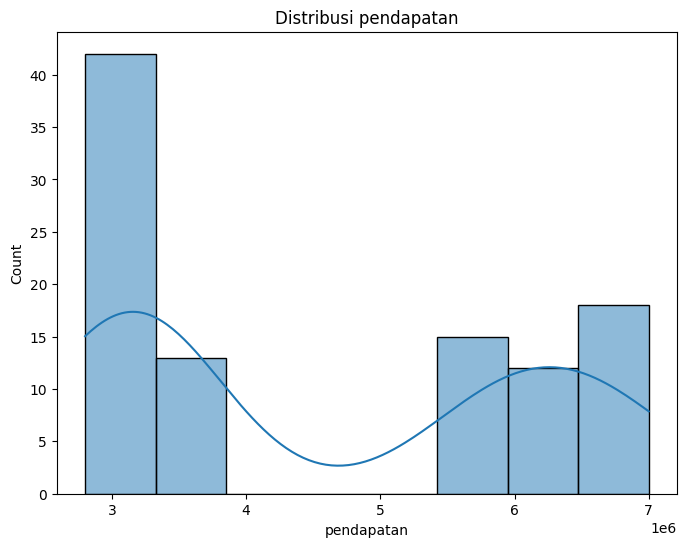

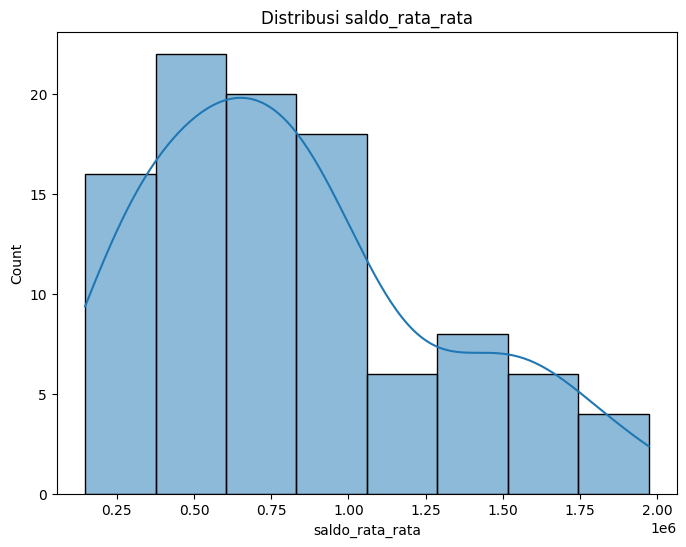

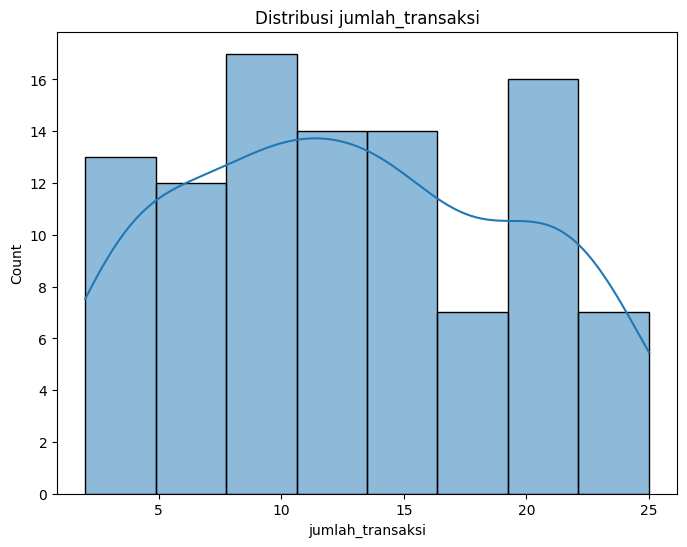

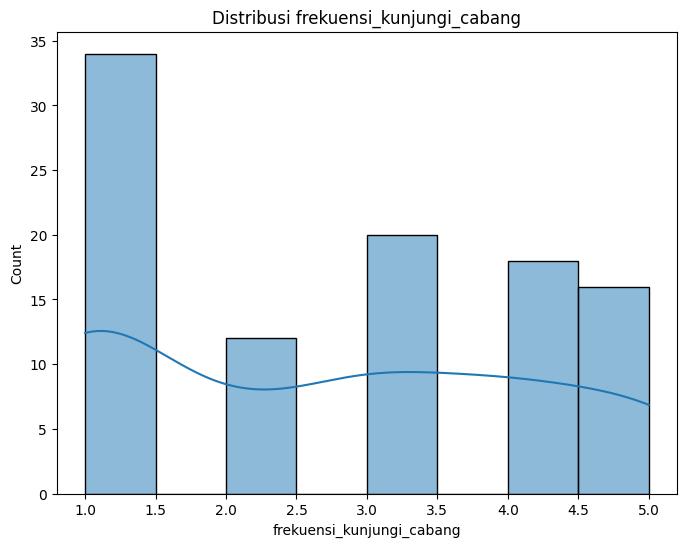

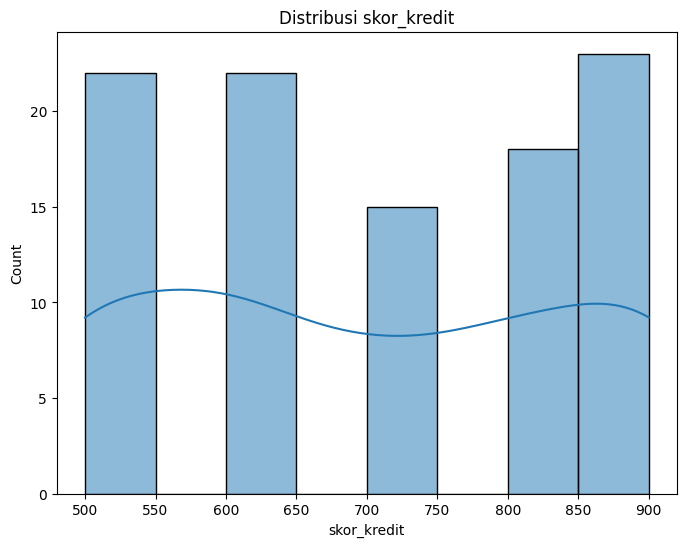

ValueError: could not convert string to float: 'N001'

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data dengan delimiter yang sesuai
data = pd.read_csv('/content/Data_Nasabah.csv', delimiter=';')

# Melihat beberapa baris pertama data
print("\nLima Baris Pertama Data:")
print(data.head())

# Informasi tentang tipe data dan skema pengkodean
print("\nInformasi Data:")
print(data.info())

# Statistik deskriptif untuk data numerik
print("\nStatistik Deskriptif:")
print(data.describe())

# Menampilkan jumlah nilai unik setiap kolom
print("\nJumlah Nilai Unik Setiap Kolom:")
for column in data.columns:
    print(f"{column}: {data[column].nunique()}")

# Analisis Distribusi Data Numerik
numerical_features = data.select_dtypes(include=['number']).columns
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[feature], kde=True)
    plt.title(f"Distribusi {feature}")
    plt.show()

# Analisis Korelasi antar Variabel
correlation_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

# Analisis Data Kategorikal
categorical_features = data.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=feature, data=data)
    plt.title(f"Jumlah Kemunculan {feature}")
    plt.xticks(rotation=45)
    plt.show()

# Analisis Nilai Hilang
missing_values = data.isnull().sum()
print("\nJumlah Nilai Hilang Setiap Kolom:")
print(missing_values)

# Analisis Outlier
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[feature])
    plt.title(f"Deteksi Outlier pada {feature}")
    plt.show()

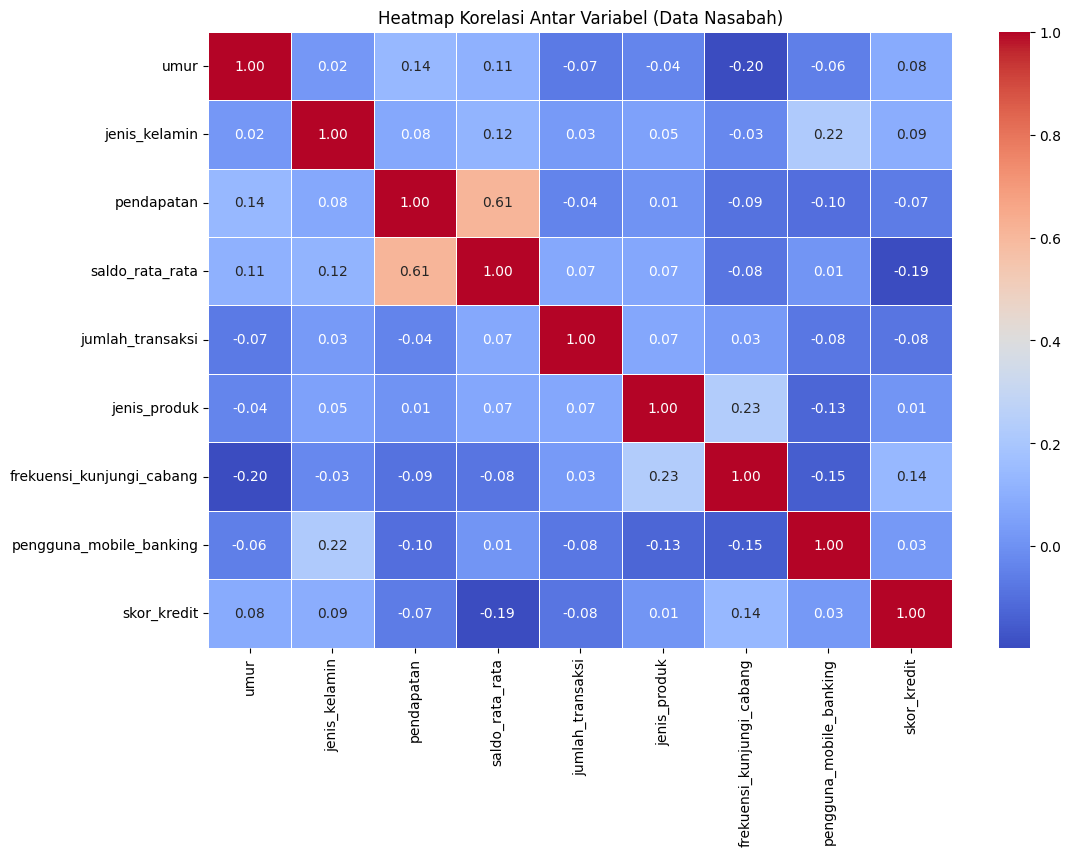

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menghitung matriks korelasi hanya untuk kolom numerik
# Menambahkan numeric_only=True untuk menghindari error pada kolom string (nasabah_id)
corr_matrix = df_nasabah.corr(numeric_only=True)

# Membuat plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel (Data Nasabah)')
plt.show()

### Validasi Data Mendalam
Bagian ini melakukan pengecekan kualitas data secara statistik dan logis untuk memastikan integritas dataset.


In [15]:
import numpy as np
from scipy import stats

# 1. Cek Duplikasi Berdasarkan nasabah_id
duplicates = df_nasabah.duplicated(subset=['nasabah_id']).sum()
print(f"Jumlah data duplikat (berdasarkan nasabah_id): {duplicates}")

# 2. Cek Validitas Logika (Nilai negatif)
negative_income = (df_nasabah['pendapatan'] < 0).sum()
negative_balance = (df_nasabah['saldo_rata_rata'] < 0).sum()
print(f"Baris dengan pendapatan negatif: {negative_income}")
print(f"Baris dengan saldo negatif: {negative_balance}")

# 3. Deteksi Outlier menggunakan Z-Score pada kolom numerik utama
numeric_cols = ['umur', 'pendapatan', 'saldo_rata_rata', 'jumlah_transaksi']
z_scores = np.abs(stats.zscore(df_nasabah[numeric_cols]))
outliers = (z_scores > 3).all(axis=1)

print(f"\nJumlah baris yang dianggap outlier ekstrem (Z-Score > 3): {outliers.sum()}")

# 4. Ringkasan Range Data
print("\nRentang Nilai Data:")
summary_range = df_nasabah[numeric_cols].agg(['min', 'max'])
display(summary_range)

Jumlah data duplikat (berdasarkan nasabah_id): 0
Baris dengan pendapatan negatif: 0
Baris dengan saldo negatif: 0

Jumlah baris yang dianggap outlier ekstrem (Z-Score > 3): 0

Rentang Nilai Data:


,umur,pendapatan,saldo_rata_rata,jumlah_transaksi
min,20,2800000,147500,2
max,64,7000000,1972000,25


### Custom Implementation
Bagian ini melakukan validasi spesifik berdasarkan logika bisnis untuk memastikan kualitas data nasabah.

In [17]:
# 1. Periksa Konsistensi Data
print("--- Validasi Konsistensi ---")

# Validasi Umur (Harus Positif)
if df_nasabah['umur'].min() < 0:
    print(f"Peringatan: Terdapat { (df_nasabah['umur'] < 0).sum() } data umur negatif.")
else:
    print("Nilai umur valid (semua positif).")

# Validasi Jenis Kelamin
# Catatan: Kita cek ke dataframe 'data' karena 'df_nasabah' sudah di-encode menjadi angka
valid_genders = ['Laki-Laki', 'Perempuan']
invalid_gender = data['jenis_kelamin'].apply(lambda x: x not in valid_genders).sum()
if invalid_gender > 0:
    print(f"Peringatan: Terdapat {invalid_gender} nilai jenis kelamin tidak standar.")
else:
    print("Nilai jenis kelamin valid.")

# 2. Deteksi Duplikat Keseluruhan
duplicate_rows = df_nasabah.duplicated().sum()
if duplicate_rows > 0:
    print(f"\n--- Deteksi Duplikat ---\nTerdapat {duplicate_rows} baris data yang identik secara keseluruhan.")
else:
    print("\n--- Deteksi Duplikat ---\nTidak ada baris data duplikat.")

# 3. Validasi Rentang Data (Outlier & Realisme)
print("\n--- Validasi Rentang Data ---")

# Cek apakah ada pendapatan yang mencurigakan (misal > 100 juta untuk dataset ini)
max_income_limit = 10000000
if df_nasabah['pendapatan'].max() > max_income_limit:
    print(f"Peringatan: Ditemukan pendapatan di atas {max_income_limit}.")
else:
    print(f"Rentang pendapatan wajar (Max: {df_nasabah['pendapatan'].max()}).")

# Cek saldo rata-rata
if df_nasabah['saldo_rata_rata'].max() > 5000000:
    print("Peringatan: Terdapat saldo rata-rata yang sangat tinggi, perlu verifikasi.")
else:
    print(f"Rentang saldo wajar (Max: {df_nasabah['saldo_rata_rata'].max()}).")

--- Validasi Konsistensi ---
Nilai umur valid (semua positif).
Nilai jenis kelamin valid.

--- Deteksi Duplikat ---
Tidak ada baris data duplikat.

--- Validasi Rentang Data ---
Rentang pendapatan wajar (Max: 7000000).
Rentang saldo wajar (Max: 1972000).


### Pemahaman Awal Dataset terhadap dataset iris
Bagian ini mengidentifikasi struktur dasar data, kualitas data (nilai hilang), dan keberadaan outlier menggunakan metode statistik.

In [18]:
# 1. Identifikasi Jumlah dan Tipe Data
print(f"Dimensi Dataset: {df_nasabah.shape[0]} baris, {df_nasabah.shape[1]} kolom")
print("\nTipe Data dan Informasi Kolom:")
df_nasabah.info()

# 2. Identifikasi Nilai yang Hilang
missing_values = df_nasabah.isnull().sum()
print("\nJumlah Nilai yang Hilang per Kolom:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada nilai yang hilang.")

# 3. Identifikasi Outlier menggunakan Metode IQR
numeric_cols = df_nasabah.select_dtypes(include=['int64', 'float64']).columns
print("\nDeteksi Outlier (Metode IQR):")

for col in numeric_cols:
    Q1 = df_nasabah[col].quantile(0.25)
    Q3 = df_nasabah[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_nasabah[col] < lower_bound) | (df_nasabah[col] > upper_bound)).sum()
    print(f"- Kolom '{col}': {outliers_count} outlier terdeteksi")

Dimensi Dataset: 100 baris, 10 kolom

Tipe Data dan Informasi Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   nasabah_id                 100 non-null    object
 1   umur                       100 non-null    int64 
 2   jenis_kelamin              100 non-null    int64 
 3   pendapatan                 100 non-null    int64 
 4   saldo_rata_rata            100 non-null    int64 
 5   jumlah_transaksi           100 non-null    int64 
 6   jenis_produk               100 non-null    int64 
 7   frekuensi_kunjungi_cabang  100 non-null    int64 
 8   pengguna_mobile_banking    100 non-null    int64 
 9   skor_kredit                100 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 7.9+ KB

Jumlah Nilai yang Hilang per Kolom:
Tidak ada nilai yang hilang.

Deteksi Outlier (Metode IQR):
- Kolom 'umur': 0 ou

### Strategi Pembersihan Data
Proses ini mencakup penanganan nilai hilang (antisipasi) dan penanganan outlier pada kolom `saldo_rata_rata`.

In [19]:
# 1. Pengisian Nilai yang Hilang (Handling Missing Values)
# Mengisi kolom numerik dengan Mean
numeric_cols = df_nasabah.select_dtypes(include=['int64', 'float64']).columns
df_nasabah[numeric_cols] = df_nasabah[numeric_cols].fillna(df_nasabah[numeric_cols].mean())

# Mengisi kolom kategorikal/object dengan Mode
object_cols = df_nasabah.select_dtypes(include=['object']).columns
for col in object_cols:
    df_nasabah[col] = df_nasabah[col].fillna(df_nasabah[col].mode()[0])

# 2. Mengoreksi Nilai Outlier (Capping/Winsorization)
# Kita tahu dari analisis sebelumnya ada 1 outlier di 'saldo_rata_rata'
Q1 = df_nasabah['saldo_rata_rata'].quantile(0.25)
Q3 = df_nasabah['saldo_rata_rata'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Terapkan capping: nilai di atas limit akan diubah menjadi nilai limit tersebut
df_nasabah['saldo_rata_rata'] = df_nasabah['saldo_rata_rata'].clip(lower=lower_limit, upper=upper_limit)

print("Pembersihan selesai:")
print("- Nilai hilang telah ditangani (jika ada).")
print(f"- Outlier pada 'saldo_rata_rata' telah dikoreksi (Batas Atas: {upper_limit}).")

# Verifikasi ulang outlier
new_outlier_count = ((df_nasabah['saldo_rata_rata'] < lower_limit) | (df_nasabah['saldo_rata_rata'] > upper_limit)).sum()
print(f"- Jumlah outlier saldo_rata_rata sekarang: {new_outlier_count}")

Pembersihan selesai:
- Nilai hilang telah ditangani (jika ada).
- Outlier pada 'saldo_rata_rata' telah dikoreksi (Batas Atas: 1952250.0).
- Jumlah outlier saldo_rata_rata sekarang: 0


### Implementasi Pembersihan Data Sesuai Contoh
Bagian ini mengimplementasikan pengisian nilai hilang, penghapusan data salah, dan koreksi outlier dengan format kode yang Anda berikan.

In [20]:
# 1. Pengisian nilai yang hilang (jika ada)
# Menggunakan strategi: mean untuk numerik, median untuk kolom tertentu, dan mode untuk kategorikal
df_nasabah['umur'] = df_nasabah['umur'].fillna(df_nasabah['umur'].mean())
df_nasabah['saldo_rata_rata'] = df_nasabah['saldo_rata_rata'].fillna(df_nasabah['saldo_rata_rata'].median())
# Untuk kolom kategorikal, kita ambil mode[0]
df_nasabah['nasabah_id'] = df_nasabah['nasabah_id'].fillna(df_nasabah['nasabah_id'].mode()[0])

# 2. Menghapus baris dengan data yang salah (jika ada)
# Contoh: Menghapus jika ada umur yang tidak masuk akal (di bawah 0)
df_nasabah.drop(df_nasabah[df_nasabah['umur'] < 0].index, inplace=True)

# 3. Mengoreksi nilai outlier (Menggunakan IQR dan Clip)
# Kita terapkan pada kolom numerik utama seperti pada contoh Anda
numeric_features = ['umur', 'pendapatan', 'saldo_rata_rata', 'jumlah_transaksi', 'skor_kredit']

for column in numeric_features:
    Q1 = df_nasabah[column].quantile(0.25)
    Q3 = df_nasabah[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mengoreksi outlier dengan clip (sesuai kode contoh Anda)
    df_nasabah[column] = df_nasabah[column].clip(lower_bound, upper_bound)

# Setelah pembersihan data
print("\nDeskripsi statistik setelah pembersihan (Format Contoh):")
display(df_nasabah.describe())


Deskripsi statistik setelah pembersihan (Format Contoh):


,umur,jenis_kelamin,pendapatan,saldo_rata_rata,jumlah_transaksi,jenis_produk,frekuensi_kunjungi_cabang,pengguna_mobile_banking,skor_kredit
count,100.000000,100.000000,1.000000e+02,1.000000e+02,100.00000,100.000000,100.000000,100.000000,100.000000
mean,43.380000,1.470000,4.555500e+06,8.157025e+05,12.78000,2.020000,2.700000,1.500000,698.000000
std,13.232788,0.501614,1.587004e+06,4.630050e+05,6.72036,0.803779,1.494096,0.502519,149.057646
min,20.000000,1.000000,2.800000e+06,1.475000e+05,2.00000,1.000000,1.000000,1.000000,500.000000
25%,32.000000,1.000000,3.100000e+06,4.485000e+05,7.75000,1.000000,1.000000,1.000000,600.000000
50%,45.000000,1.000000,3.475000e+06,7.652500e+05,13.00000,2.000000,3.000000,1.500000,700.000000
75%,54.250000,2.000000,6.225000e+06,1.050000e+06,18.25000,3.000000,4.000000,2.000000,800.000000
max,64.000000,2.000000,7.000000e+06,1.952250e+06,25.00000,3.000000,5.000000,2.000000,900.000000


### Identifikasi dan Pelabelan Data sesuai SOP
Tahap ini melakukan pemetaan (mapping) dari nilai numerik atau kategori ke label teks yang sesuai dengan standar operasional prosedur (SOP).

In [21]:
# Identifikasi data target dan lakukan pelabelan

# Misalkan berdasarkan SOP, kita ingin memberikan label pada 'jenis_produk'
# 1: Tabungan Biasa
# 2: Kartu Kredit Utama
# 3: Deposito Berjangka

label_mapping_produk = {
    1: 'Tabungan Biasa',
    2: 'Kartu Kredit Utama',
    3: 'Deposito Berjangka'
}

# Buat kolom baru 'produk_label' yang berisi label teks
df_nasabah['produk_label'] = df_nasabah['jenis_produk'].map(label_mapping_produk)

# Tambahan: Pelabelan Skor Kredit berdasarkan SOP Resiko
def labeling_resiko(skor):
    if skor >= 800: return 'Risiko Rendah'
    elif skor >= 600: return 'Risiko Sedang'
    else: return 'Risiko Tinggi'

df_nasabah['kategori_risiko'] = df_nasabah['skor_kredit'].apply(labeling_resiko)

# Tampilkan data dengan label baru
print("\nData dengan label berdasarkan SOP (Format Contoh):")
display(df_nasabah[['nasabah_id', 'jenis_produk', 'produk_label', 'skor_kredit', 'kategori_risiko']].head())


Data dengan label berdasarkan SOP (Format Contoh):


,nasabah_id,jenis_produk,produk_label,skor_kredit,kategori_risiko
0,N001,1,Tabungan Biasa,900,Risiko Rendah
1,N002,2,Kartu Kredit Utama,900,Risiko Rendah
2,N003,1,Tabungan Biasa,500,Risiko Tinggi
3,N004,3,Deposito Berjangka,700,Risiko Sedang
4,N005,2,Kartu Kredit Utama,800,Risiko Rendah
